In [1]:
# Installazione delle librerie Python necessarie per il progetto
%pip install kagglehub matplotlib scikit-learn pandas keras numpy tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Analisi Dataset

Setup iniziale per la creazione della directory dove salvare le visualizzazioni generate durante l'analisi.

In [2]:
import os

# Crea la cartella per salvare i grafici generati
os.makedirs("images", exist_ok=True)

Caricamento del dataset dal repository UCI e preparazione del DataFrame per l'analisi esplorativa.

In [3]:
import kagglehub
import numpy as np
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

# Utilizza il dataset cardio_train.csv
df = pd.read_csv(os.path.join(path, "cardio_train.csv"), sep=";")
df.head()

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Analisi preliminare dei tipi di dati e delle statistiche descrittive per comprendere la struttura del dataset.

In [4]:
# Mostra i tipi di dato di ciascuna feature
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Preparazione delle feature per il machine learning rimuovendo colonne non predittive e isolando la variabile target.

In [5]:
# Rimuove ID (non predittivo) e target (da predire) per ottenere solo le features
features = df.drop(columns=["id", "cardio"]).copy()

# Converte gender da (1,2) a (0,1) per coerenza con le altre binarie
features["gender"] = features["gender"] - 1

Identificazione delle feature numeriche, binarie ed ordinali

In [6]:
# Definizione dei tipi di feature
numeric_features = ["age", "height", "weight", "ap_hi", "ap_lo"]
binary_features = ["gender", "smoke", "alco", "active"]
ordinal_features = ["cholesterol", "gluc"]

print(f"Feature numeriche: {numeric_features}")
print(f"Feature binarie: {binary_features}")
print(f"Feature ordinali: {ordinal_features}")

# Target
y = df["cardio"].values

Feature numeriche: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
Feature binarie: ['gender', 'smoke', 'alco', 'active']
Feature ordinali: ['cholesterol', 'gluc']


In [7]:
# Calcola le statistiche descrittive (media, std, min, max, quartili)
features.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000


In [8]:
# Applica One-Hot Encoding alle feature ordinali per le reti neurali
features_nn = pd.get_dummies(
    features, columns=ordinal_features, drop_first=False, dtype=int
)

# Identifica le colonne One-Hot generate
onehot_cols = [
    col for col in features_nn.columns if col not in numeric_features + binary_features
]

# Lista completa delle feature per NN
all_features_nn = numeric_features + binary_features + onehot_cols
FEATURES_NUMBER_NN = len(all_features_nn)

print(f"\nDataset per Reti Neurali:")
print(f"  Dimensioni: {features_nn.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_NN}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(onehot_cols)} One-Hot encoded")
print(f"\nColonne One-Hot: {onehot_cols}")


Dataset per Reti Neurali:
  Dimensioni: (70000, 15)
  Feature totali: 15
  - 5 numeriche
  - 4 binarie
  - 6 One-Hot encoded

Colonne One-Hot: ['cholesterol_1', 'cholesterol_2', 'cholesterol_3', 'gluc_1', 'gluc_2', 'gluc_3']


In [9]:
# Mantieni le feature ordinali come interi per Decision Tree
features_dt = features.copy()

# Converte le ordinali da category a int per interpretabilità
for col in ordinal_features:
    features_dt[col] = features_dt[col].astype(int)

# Lista completa delle feature per DT
all_features_dt = numeric_features + binary_features + ordinal_features
FEATURES_NUMBER_DT = len(all_features_dt)

# Prepara array per DT (NON SCALATO)
X_dt = features_dt[all_features_dt].values

print(f"\nDataset per Decision Tree:")
print(f"  Dimensioni: {X_dt.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_DT}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(ordinal_features)} ordinali (come interi)")
print(f"\nFeature ordinali come interi: {ordinal_features}")


Dataset per Decision Tree:
  Dimensioni: (70000, 11)
  Feature totali: 11
  - 5 numeriche
  - 4 binarie
  - 2 ordinali (come interi)

Feature ordinali come interi: ['cholesterol', 'gluc']


## Preparazione Dati

In [10]:
from sklearn.preprocessing import StandardScaler

# Scala solo le feature numeriche
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(features_nn[numeric_features])

# Mantieni binarie e One-Hot inalterate (0/1)
binary_onehot_data = features_nn[binary_features + onehot_cols].values

# Concatena le feature scalate e non scalate
X_nn = np.concatenate([numeric_scaled, binary_onehot_data], axis=1)

print(f"Dati per Reti Neurali - Shape: {X_nn.shape}")

Dati per Reti Neurali - Shape: (70000, 15)


In [11]:
# Calcola la distribuzione percentuale delle classi
class_distribution = df["cardio"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


## Splitting del Dataset

Suddivisione del dataset in training set (70%) e test set (30%) per entrambi gli approcci (NN e DT).

### Reti Neurali

In [12]:
from sklearn.model_selection import train_test_split

# Split per Reti Neurali (dati scalati con One-Hot)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y, test_size=0.3, random_state=42
)

print(f"Split Reti Neurali:")
print(f"  Training: {X_train_nn.shape}, Test: {X_test_nn.shape}")

Split Reti Neurali:
  Training: (49000, 15), Test: (21000, 15)


### Decision Tree

In [13]:
# Split per Decision Tree (dati NON scalati, ordinali come interi)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y, test_size=0.3, random_state=42
)


print(f"\nSplit Decision Tree:")
print(f"  Training: {X_train_dt.shape}, Test: {X_test_dt.shape}")


Split Decision Tree:
  Training: (49000, 11), Test: (21000, 11)


# Reti Neurali

Importazione delle librerie necessarie per la creazione e il training delle reti neurali.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

Funzione di valutazione completa per analizzare le performance dei modelli di rete neurale.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV


# Valuta e visualizza le performance di un modello di rete neurale
def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Predice probabilità e applica threshold
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Calcola e visualizza matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa metriche di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcola curva ROC e AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    # Baseline random classifier
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_roc_curve_{file_suffix}.svg", format="svg", bbox_inches="tight"
    )
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Visualizza loss e accuracy durante training
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"images/nn_training_curves_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

## Standard Dataset

Creazione e training di una rete neurale con architettura sequenziale su dataset standard non bilanciato.

In [16]:
# Crea modello sequenziale con 3 layer nascosti
model = Sequential()

# Layer nascosti: 128 -> 64 -> 32 neuroni con ReLU e Dropout
model.add(Dense(128, input_shape=(FEATURES_NUMBER_NN,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Layer output con sigmoid per classificazione binaria
model.add(Dense(1, activation="sigmoid"))

# Compila con binary crossentropy
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# Training con 150 epoche e validation split 10%
history = model.fit(
    X_train_nn, y_train_nn, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6293 - loss: 0.6453 - val_accuracy: 0.6722 - val_loss: 0.6078
Epoch 2/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6849 - loss: 0.6095 - val_accuracy: 0.7224 - val_loss: 0.5686
Epoch 3/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7117 - loss: 0.5862 - val_accuracy: 0.7282 - val_loss: 0.5562
Epoch 4/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7196 - loss: 0.5741 - val_accuracy: 0.7327 - val_loss: 0.5485
Epoch 5/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7252 - loss: 0.5642 - val_accuracy: 0.7339 - val_loss: 0.5466
Epoch 6/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7284 - loss: 0.5587 - val_accuracy: 0.7359 - val_loss: 0.5450
Epoch 7/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7294 - loss: 0.5556 - val_accuracy: 0.7331 - val_loss: 0.5444
Epoch 8/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7292 - loss: 0.5540 - val_accu

### Risultati e Metriche

657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step


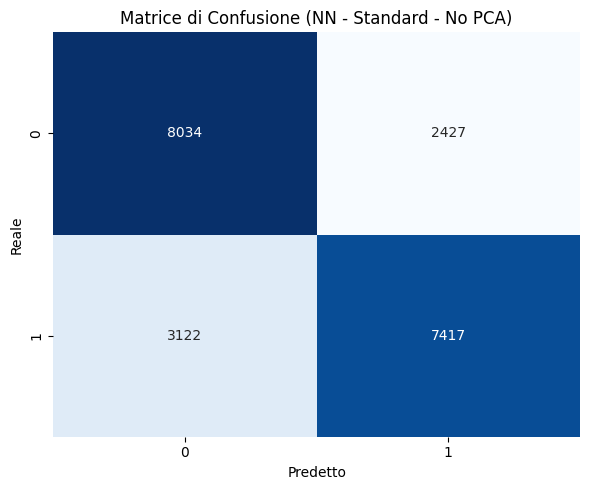

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74     10461
           1       0.75      0.70      0.73     10539

    accuracy                           0.74     21000
   macro avg       0.74      0.74      0.74     21000
weighted avg       0.74      0.74      0.74     21000



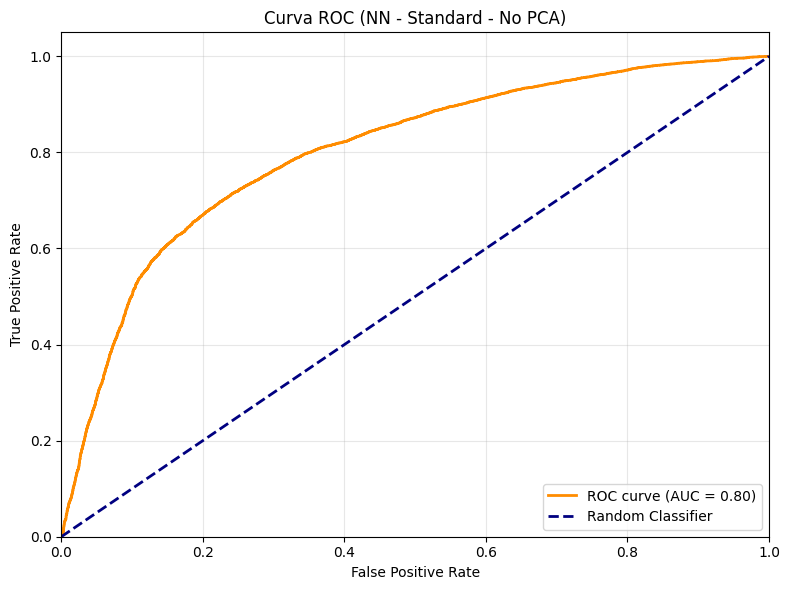


AUC Score: 0.8002


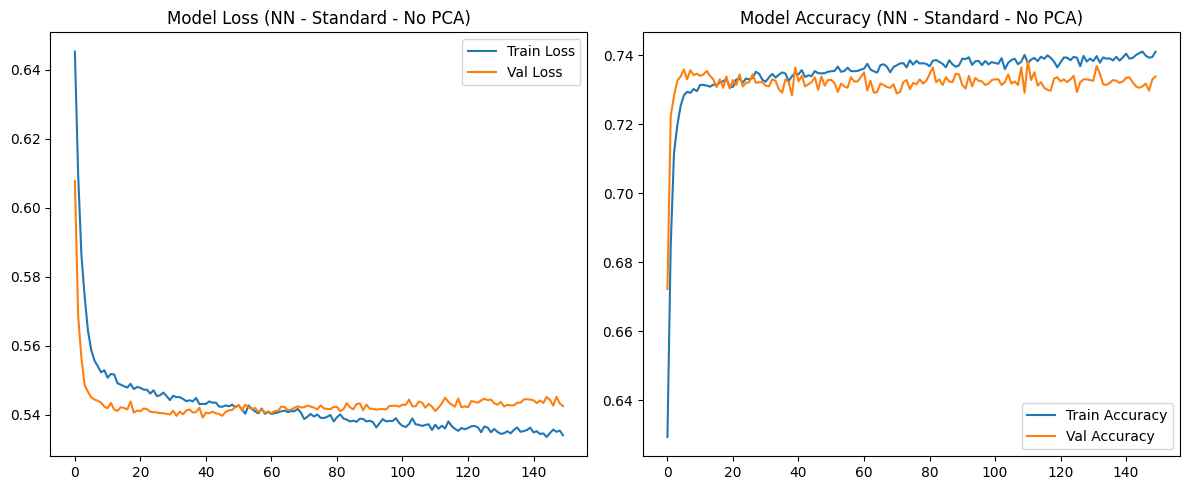

In [17]:
# Valuta il modello e genera grafici delle metriche
evaluate_and_plot(
    model, X_test_nn, y_test_nn, history, title_suffix="NN - Standard - No PCA"
)

## Class Weight

Rete neurale addestrata con pesi di classe bilanciati per gestire lo sbilanciamento durante il training.

In [18]:
# Calcola pesi bilanciati per le classi
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_nn), y=y_train_nn
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# Architettura: 128 -> 64 -> 32
model_class_weights = Sequential()

model_class_weights.add(
    Dense(128, input_shape=(FEATURES_NUMBER_NN,), activation="relu")
)
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(64, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(32, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(1, activation="sigmoid"))

model_class_weights.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con class_weight
history_class_weights = model_class_weights.fit(
    X_train_nn,
    y_train_nn,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.997557003257329), 1: np.float64(1.0024549918166938)}


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6405 - loss: 0.6384 - val_accuracy: 0.6822 - val_loss: 0.6023
Epoch 2/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6853 - loss: 0.6070 - val_accuracy: 0.7163 - val_loss: 0.5674
Epoch 3/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7118 - loss: 0.5838 - val_accuracy: 0.7284 - val_loss: 0.5597
Epoch 4/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7236 - loss: 0.5737 - val_accuracy: 0.7331 - val_loss: 0.5513
Epoch 5/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7250 - loss: 0.5661 - val_accuracy: 0.7349 - val_loss: 0.5459
Epoch 6/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7280 - loss: 0.5592 - val_accuracy: 0.7341 - val_loss: 0.5464
Epoch 7/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7271 - loss: 0.5550 - val_accuracy: 0.7343 - val_loss: 0.5445
Epoch 8/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7291 - loss: 0.5552 - val_accu

### Risultati e Metriche

657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step


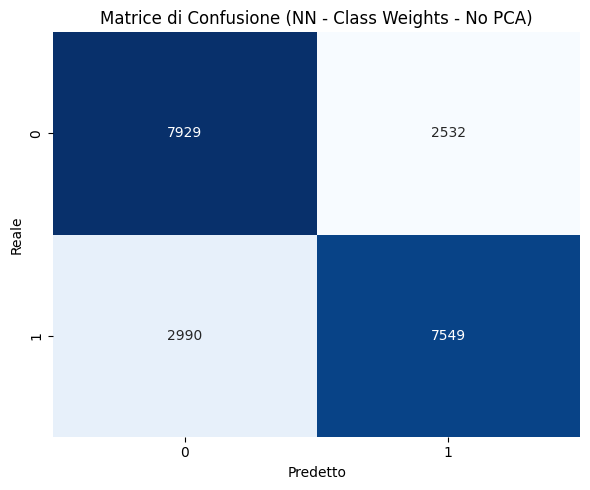

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.73      0.76      0.74     10461
           1       0.75      0.72      0.73     10539

    accuracy                           0.74     21000
   macro avg       0.74      0.74      0.74     21000
weighted avg       0.74      0.74      0.74     21000



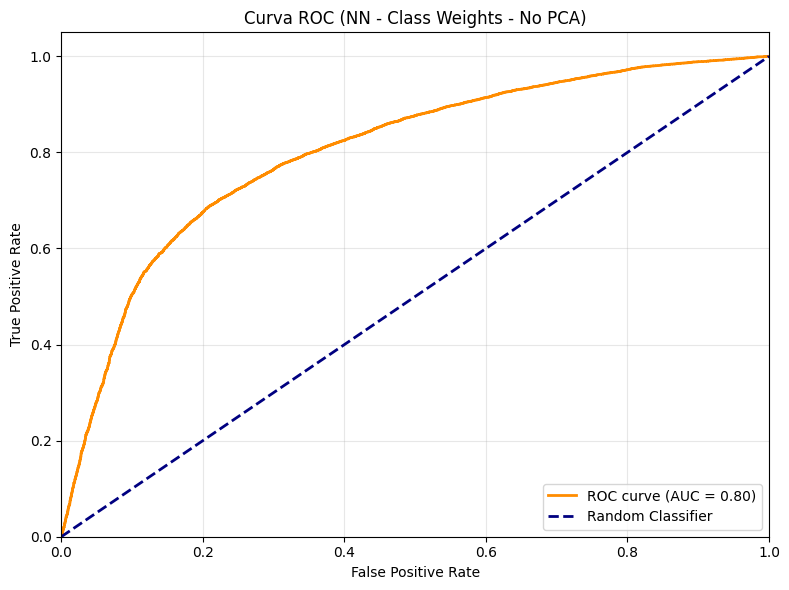


AUC Score: 0.8008


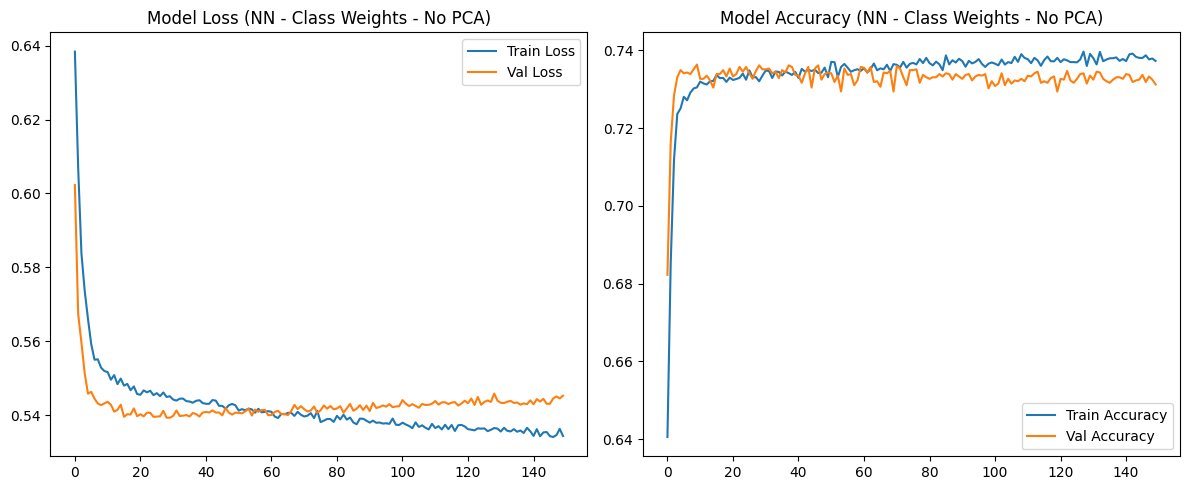

In [19]:
# Valuta modello con class weights
evaluate_and_plot(
    model_class_weights,
    X_test_nn,
    y_test_nn,
    history_class_weights,
    title_suffix="NN - Class Weights - No PCA",
)

# Alberi di Decisione

Definizione delle funzioni di supporto per visualizzazione e valutazione degli alberi di decisione.

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
import pandas as pd


# Calcola e visualizza le metriche di performance dell'albero
def show_tree_metrics(tree, y_test, y_pred, title_suffix):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Caratteristiche strutturali albero
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/dt_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


# Visualizza la struttura dell'albero di decisione
def print_tree(tree, max_depth, title, feature_names):
    file_suffix = (
        title.lower().replace(" ", "_").replace("-", "") if title else "decision_tree"
    )
    plt.figure(figsize=(50, 24))

    # Genera grafico albero con nodi colorati
    plot_tree(
        tree,
        filled=True,
        feature_names=feature_names,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/dt_{file_suffix}.svg", format="svg", bbox_inches="tight")
    plt.show()

Funzione per analizzare e visualizzare l'importanza delle feature nell'albero di decisione.

In [21]:
# Visualizza l'importanza delle feature nell'albero
def plot_feature_importance(tree, feature_names, title_suffix, top_n=None):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Estrae feature importance dall'albero
    importances = tree.feature_importances_

    # Crea DataFrame e ordina per importanza
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Limita alle top_n feature
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Crea grafico a barre orizzontali
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df["importance"])
    plt.yticks(range(len(importance_df)), importance_df["feature"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    title = "Feature Importance" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(
        f"images/dt_feature_importance_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa valori
    print(f"\nFeature Importance{' (' + title_suffix + ')' if title_suffix else ''}:")
    print(importance_df.to_string(index=False))

Funzione per eseguire Grid Search con cross-validation per trovare i migliori iperparametri.

In [22]:
# Esegue Grid Search per trovare i migliori iperparametri
def run_grid_search(
    X_train, y_train, param_grid, class_weight="balanced", cv=5, scoring="f1"
):
    base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight)

    # Inizializza Grid Search con cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{'='*60}")
    print(f"RISULTATI GRID SEARCH (scoring={scoring}, cv={cv})")
    print(f"{'='*60}")
    print(f"Migliori parametri: {grid_search.best_params_}")
    print(f"Miglior score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"{'='*60}\n")

    return grid_search.best_estimator_, grid_search

Definizione della griglia di iperparametri da testare con Grid Search.

In [23]:
# Griglia iperparametri per Grid Search
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

## Standard Dataset

In [24]:
# Esegue Grid Search senza class weights sui dati non scalati
dt_standard, grid_search_standard = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight=None
)
y_pred_standard = dt_standard.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7267



### Risultati e Metriche

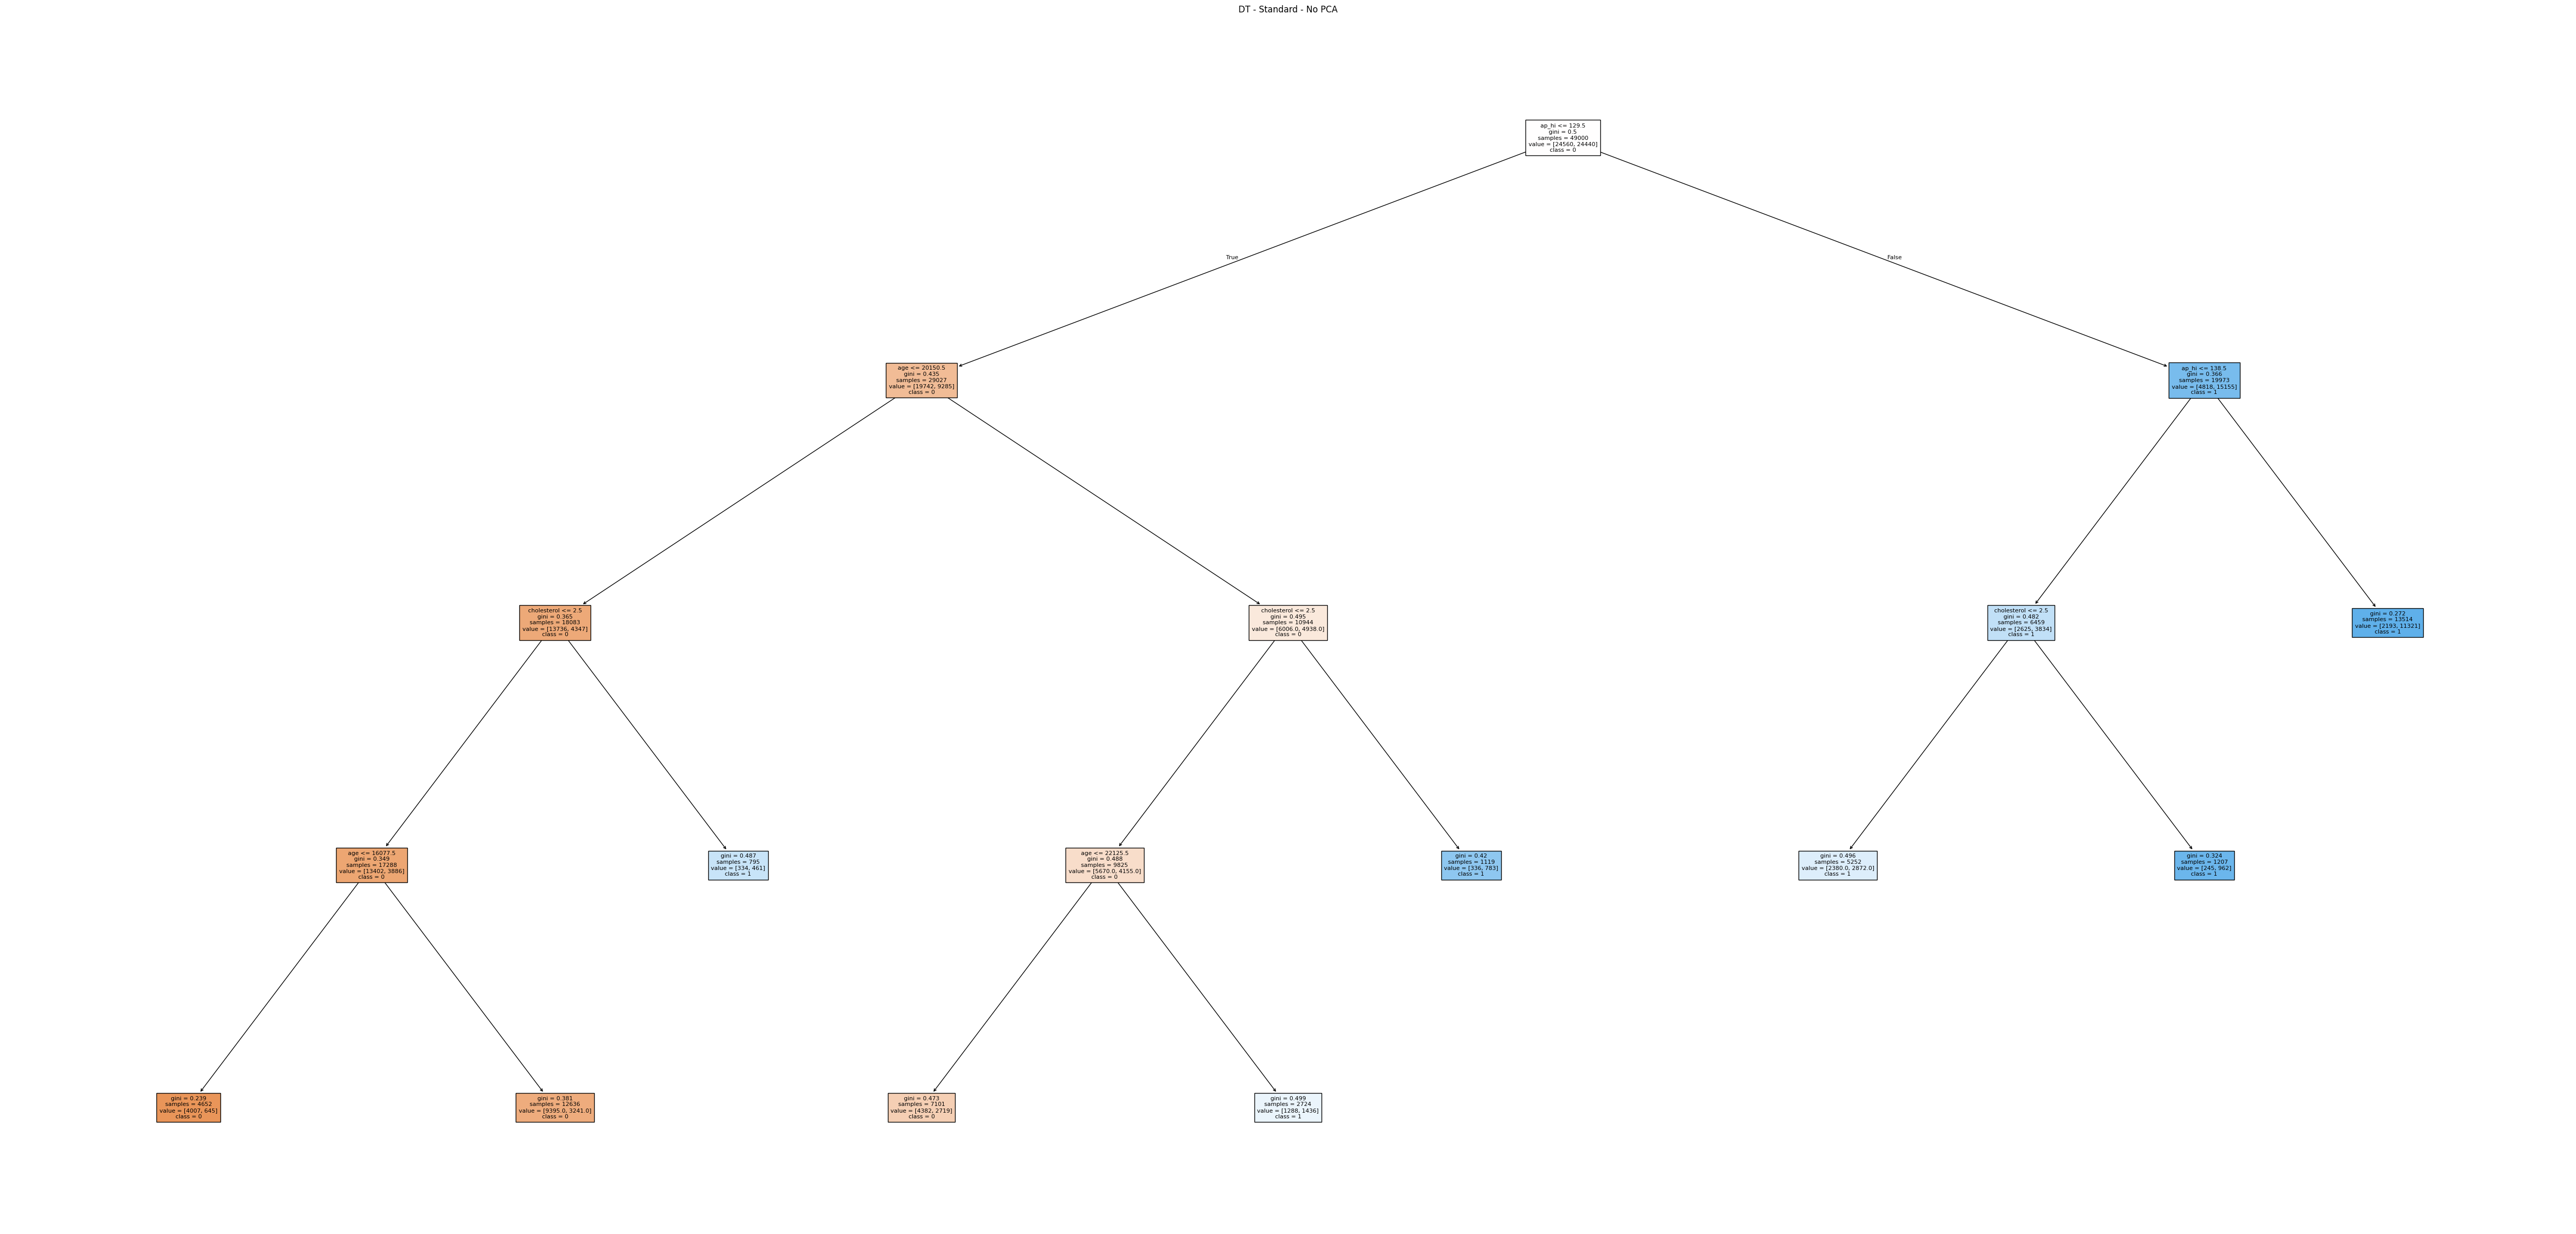

Accuracy: 0.7318
Profondità albero: 4
Numero di foglie: 9


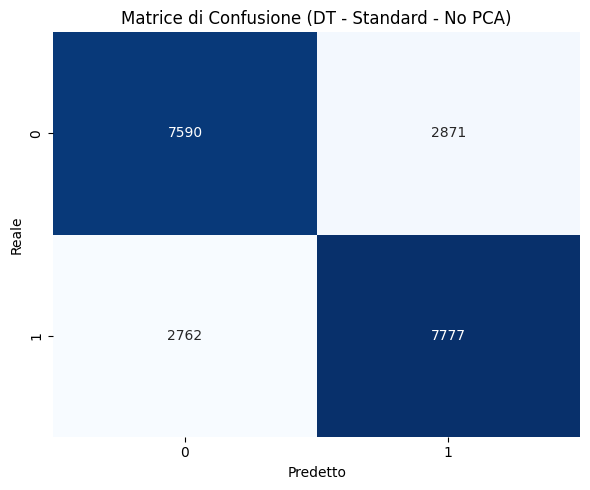


              precision    recall  f1-score   support

           0       0.73      0.73      0.73     10461
           1       0.73      0.74      0.73     10539

    accuracy                           0.73     21000
   macro avg       0.73      0.73      0.73     21000
weighted avg       0.73      0.73      0.73     21000



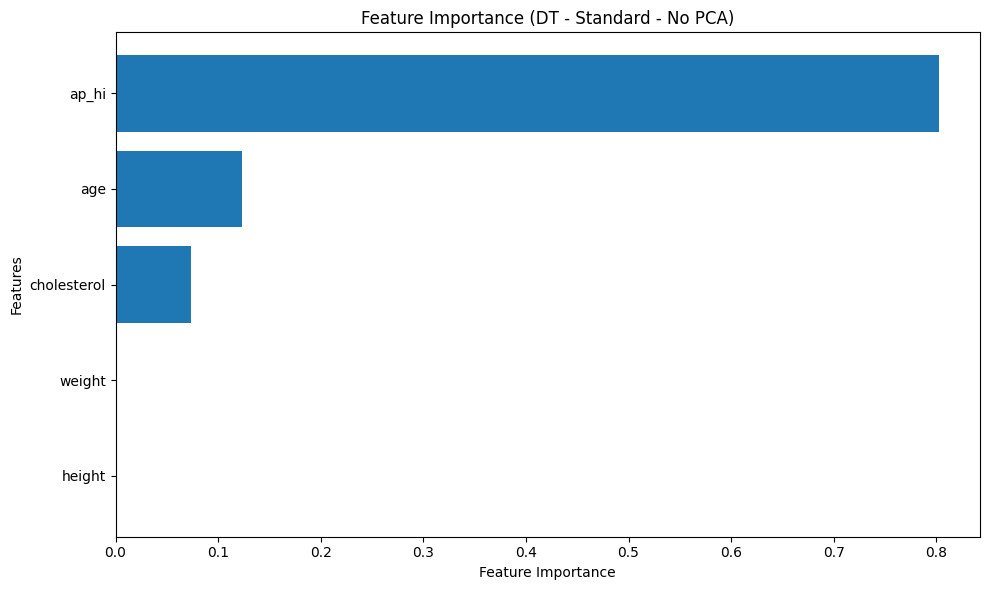


Feature Importance (DT - Standard - No PCA):
    feature  importance
      ap_hi    0.802394
        age    0.123595
cholesterol    0.074010
     weight    0.000000
     height    0.000000


In [25]:
# Visualizza albero
print_tree(
    dt_standard,
    max_depth=dt_standard.get_depth(),
    title="DT - Standard - No PCA",
    feature_names=all_features_dt,
)
show_tree_metrics(
    dt_standard, y_test_dt, y_pred_standard, title_suffix="DT - Standard - No PCA"
)
plot_feature_importance(
    dt_standard,
    feature_names=all_features_dt,
    title_suffix="DT - Standard - No PCA",
    top_n=5,
)

## Class Weight

Grid Search con class weights per gestire lo sbilanciamento delle classi.

In [26]:
# Grid Search con class_weight='balanced' sui dati NON SCALATI
dt_class_weights, grid_search_class_weights = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight="balanced", scoring="f1"
)

y_pred_class_weights = dt_class_weights.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7267



### Risultati e Metriche

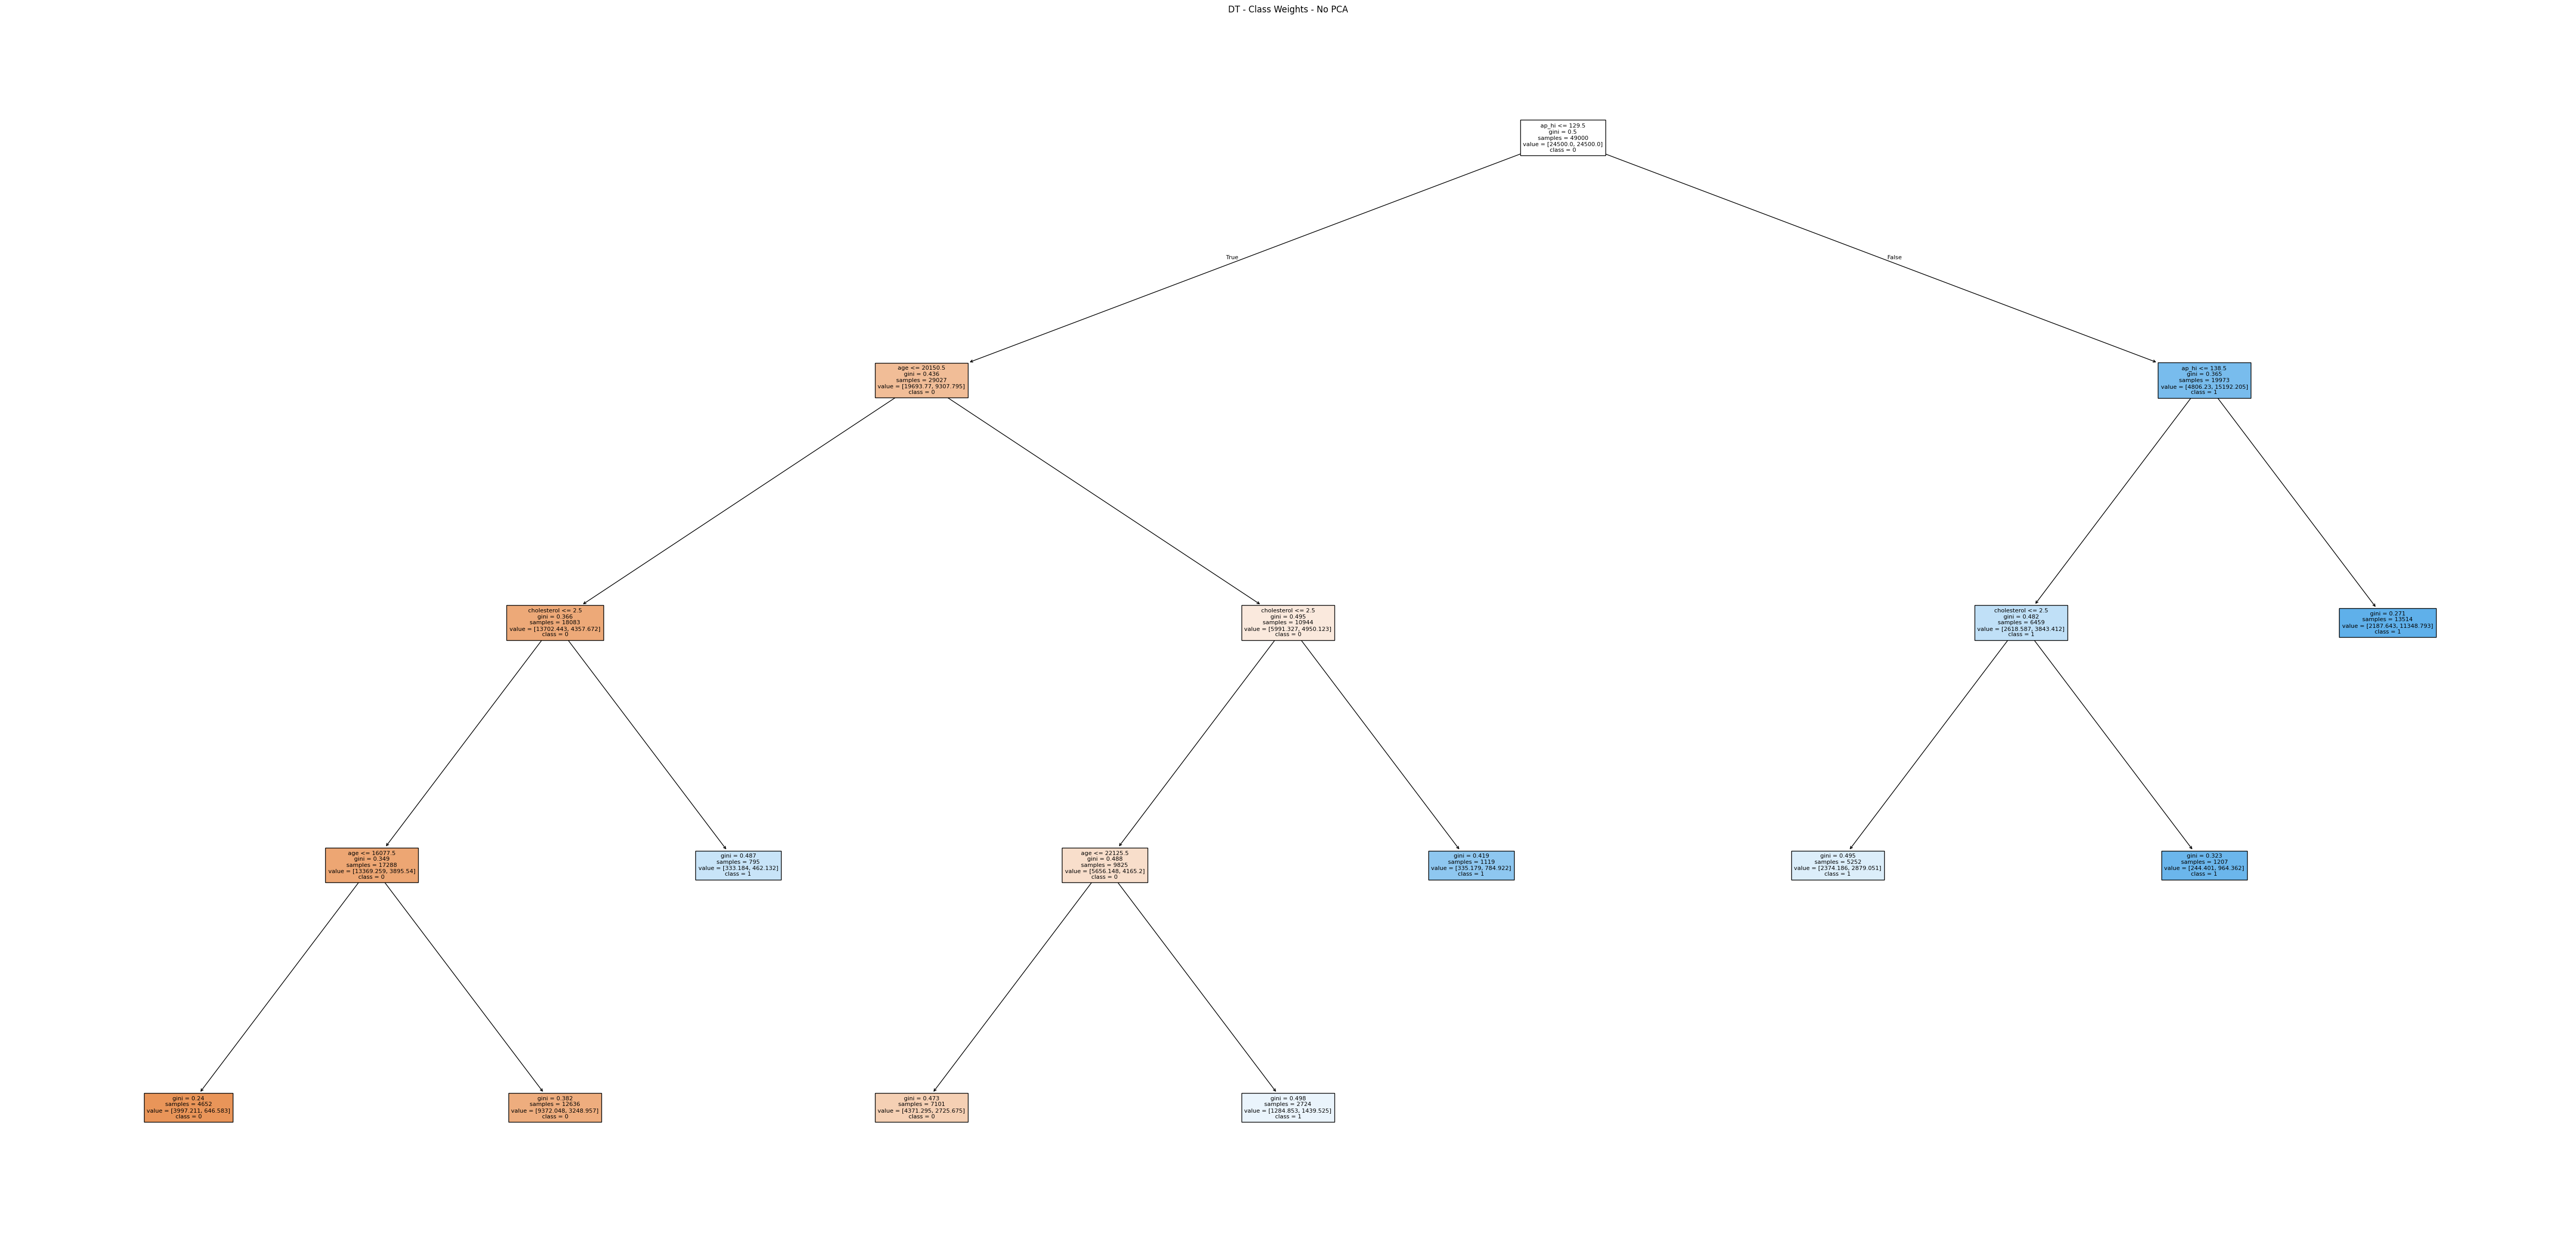

Accuracy: 0.7318
Profondità albero: 4
Numero di foglie: 9


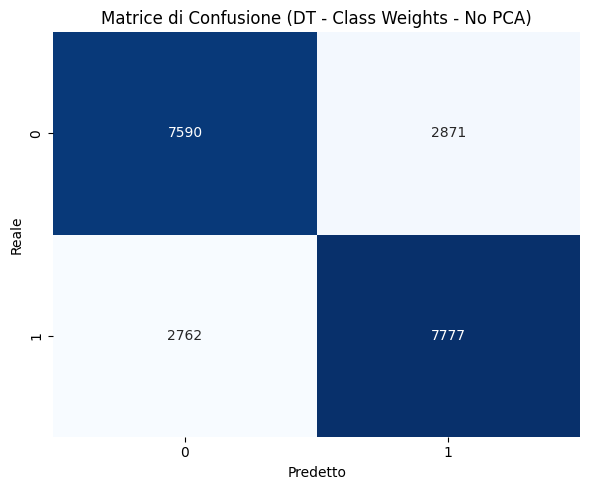


              precision    recall  f1-score   support

           0       0.73      0.73      0.73     10461
           1       0.73      0.74      0.73     10539

    accuracy                           0.73     21000
   macro avg       0.73      0.73      0.73     21000
weighted avg       0.73      0.73      0.73     21000



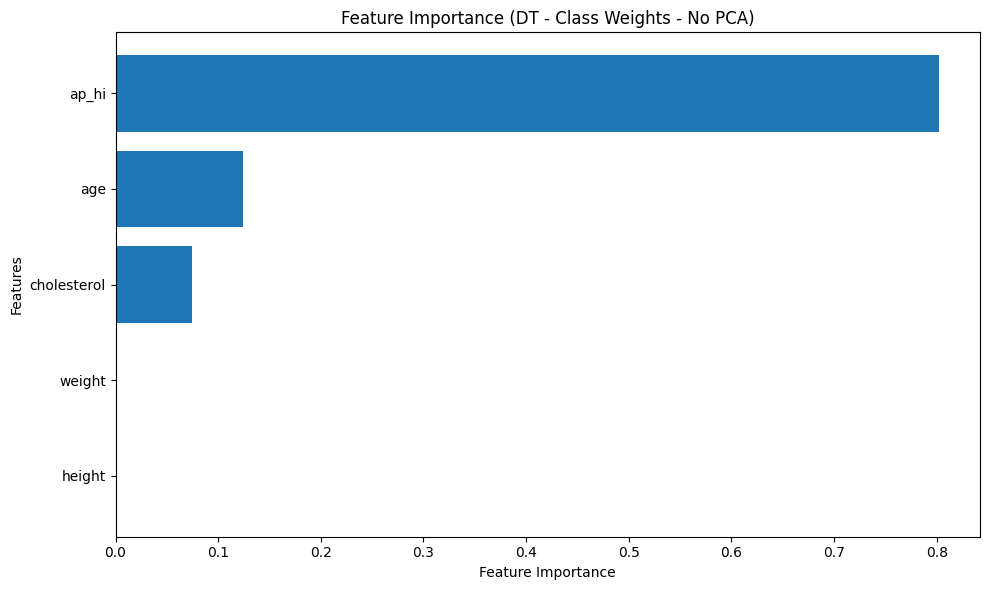


Feature Importance (DT - Class Weights - No PCA):
    feature  importance
      ap_hi    0.802027
        age    0.123928
cholesterol    0.074045
     weight    0.000000
     height    0.000000


In [27]:
# Visualizza albero con class weights
print_tree(
    dt_class_weights,
    dt_class_weights.get_depth(),
    "DT - Class Weights - No PCA",
    all_features_dt,
)
show_tree_metrics(
    dt_class_weights, y_test_dt, y_pred_class_weights, "DT - Class Weights - No PCA"
)

plot_feature_importance(
    dt_class_weights, all_features_dt, "DT - Class Weights - No PCA", top_n=5
)